**How many unique terms and proteins are there?**

Number of unique GO terms:  26125

Number of unique proteins:  82404

In [1]:
import pandas as pd

from os import path
from utils.io import get_data_path

terms_df = pd.read_csv(get_data_path("cafa6", path.join("Train", "train_terms.tsv")), sep="\t")
term_counts = terms_df.term.value_counts()
protein_counts = terms_df.EntryID.value_counts()
print("Number of unique GO terms: ", len(term_counts))
print("Number of unique proteins: ", len(protein_counts))

Number of unique GO terms:  26125
Number of unique proteins:  82404


**How often does each GO term appear? (top 100 terms)**

Follow a power law distribution

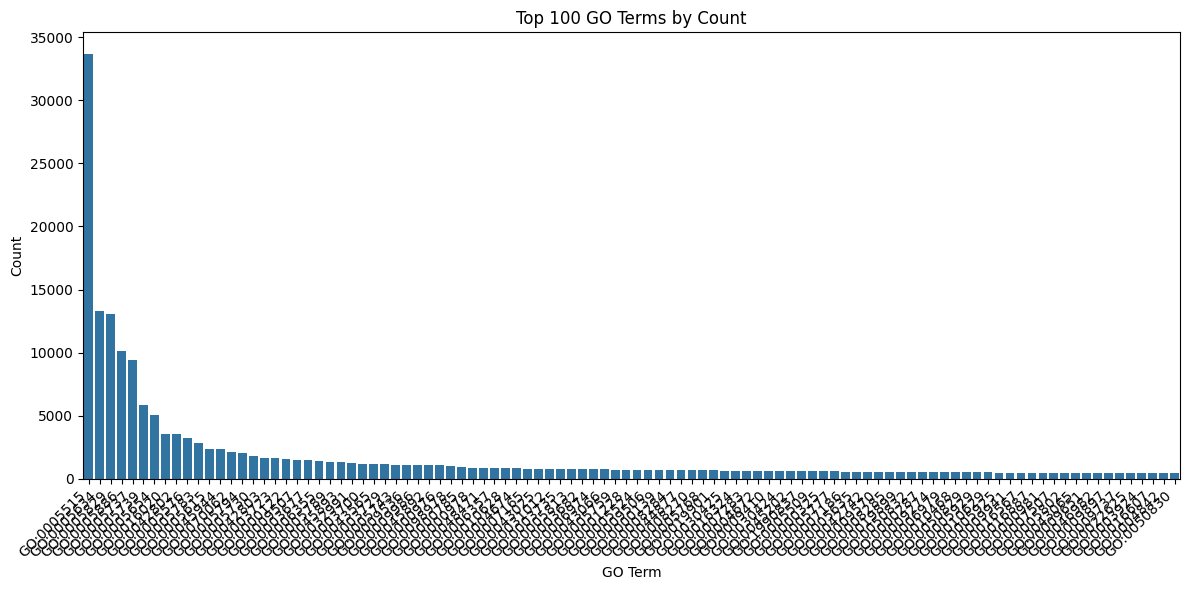

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot top 20 GO terms by count
top_terms = term_counts.head(100)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_terms.index, y=top_terms.values)
plt.xlabel("GO Term")
plt.ylabel("Count")
plt.title("Top 100 GO Terms by Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**How many annotations does each protein have?**

Follows a power law distribution, mean 6.5 - median 4.0

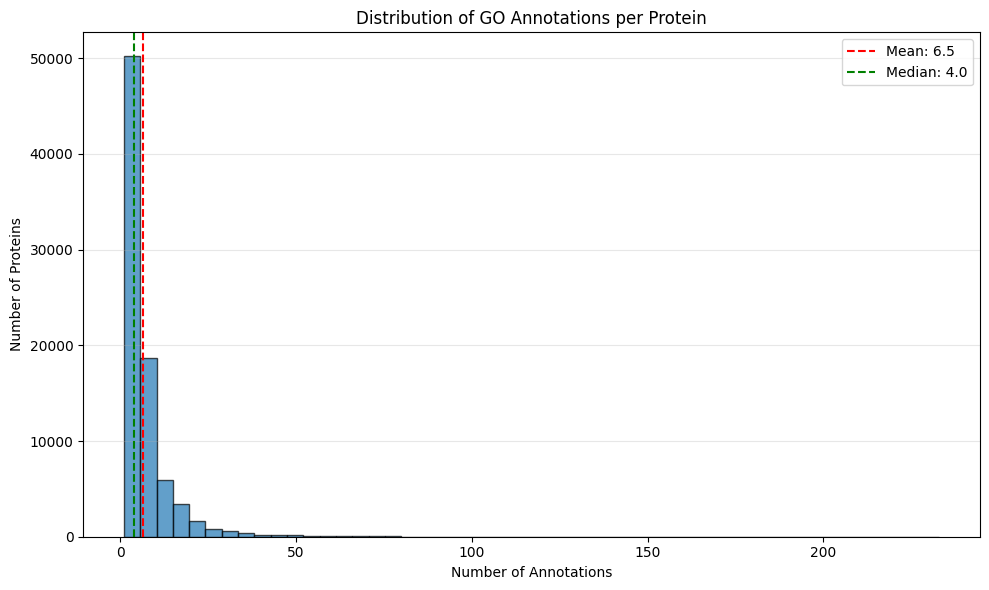

In [3]:
# Count annotations per protein
annotations_per_protein = terms_df.groupby("EntryID").size()

# Create histogram
plt.figure(figsize=(10, 6))
plt.hist(annotations_per_protein, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Number of Annotations")
plt.ylabel("Number of Proteins")
plt.title("Distribution of GO Annotations per Protein")
plt.grid(axis='y', alpha=0.3)

# Add mean and median lines
mean_val = annotations_per_protein.mean()
median_val = annotations_per_protein.median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
plt.legend()

plt.tight_layout()
plt.show()

**What is the distribution of annotations in the ground truth?**

Most are BPO (biological process) - example: DNA replication

A smaller amount are MFO and an even smaller amount CCO.


Aspect counts and percentages:
  biological_process: 16,858 (64.5%)
  molecular_function: 6,616 (25.3%)
  cellular_component: 2,651 (10.1%)


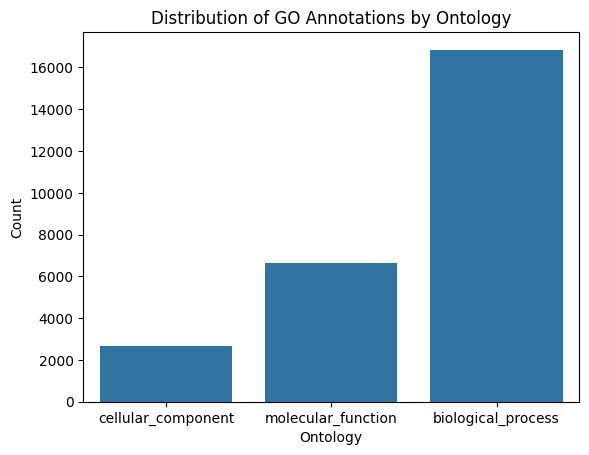

In [21]:
# Map aspect letters to full names
aspect_map = {
    "P": "biological_process",
    "F": "molecular_function",
    "C": "cellular_component"
}
terms_df["aspect_name"] = terms_df["aspect"].map(aspect_map)

# Count of annotations by aspect (GO ontology category)
aspects = terms_df.drop(columns=["EntryID"]).drop_duplicates()
aspect_counts = aspects["aspect_name"].value_counts()
aspect_pcts = aspects["aspect_name"].value_counts(normalize=True) * 100

print("Aspect counts and percentages:")
for aspect in aspect_counts.index:
    print(f"  {aspect}: {aspect_counts[aspect]:,} ({aspect_pcts[aspect]:.1f}%)")

sns.countplot(data=aspects, x="aspect_name")
plt.xlabel("Ontology")
plt.ylabel("Count")
plt.title("Distribution of GO Annotations by Ontology")
plt.show()

**What is the distribution of annotations that exist in general?**

The distribution between training and all annotations looks quite similar.

Ontology counts and percentages:
  biological_process: 25,950 (64.7%)
  molecular_function: 10,131 (25.3%)
  cellular_component: 4,041 (10.1%)


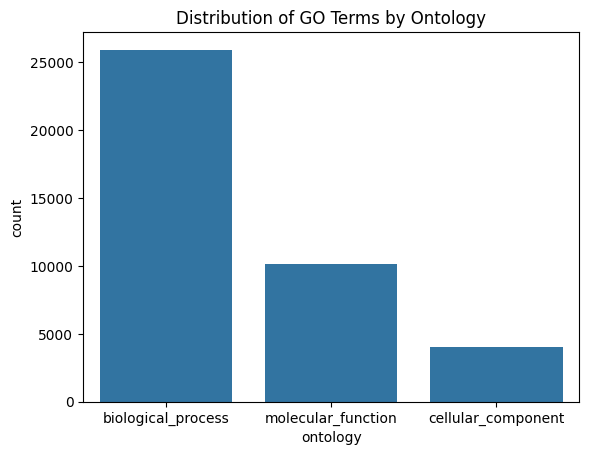

In [15]:
import obonet

graph = obonet.read_obo(get_data_path("cafa6", path.join("Train", "go-basic.obo")))
terms = []
ontologies = []
for node in graph.nodes:
    data = graph.nodes[node]
    if "namespace" in data:
        terms.append(node)
        ontologies.append(data["namespace"])
ontology_df = pd.DataFrame({"term": terms, "ontology": ontologies})
ontology_counts = ontology_df["ontology"].value_counts()
ontology_pcts = ontology_df["ontology"].value_counts(normalize=True) * 100

print("Ontology counts and percentages:")
for ontology in ontology_counts.index:
    print(f"  {ontology}: {ontology_counts[ontology]:,} ({ontology_pcts[ontology]:.1f}%)")

sns.countplot(data=ontology_df, x="ontology")
plt.title("Distribution of GO Terms by Ontology")
plt.show()

**What percentage of GO terms are present in the training data?**

65.11%

In [29]:
training_terms = len(terms_df.term.unique())
all_terms = len(ontology_df.term.unique())
print(f"Number of unique GO terms in training data: {training_terms} / {all_terms}")
print(f"Percentage of GO terms covered in training data: {training_terms / all_terms * 100:.2f}%")

Number of unique GO terms in training data: 26125 / 40122
Percentage of GO terms covered in training data: 65.11%


**What is the distribution of GO term depths? (Root ontologies BPO, CCO, MFO have depth 0)**

The distribution is slightly right-skewed, with the mean and median both around 5.

Unique GO terms with valid depth: 26,125 / 26,125

Depth statistics (unique GO terms):
count    26125.000000
mean         4.789474
std          1.414026
min          1.000000
25%          4.000000
50%          5.000000
75%          6.000000
max         11.000000
dtype: float64


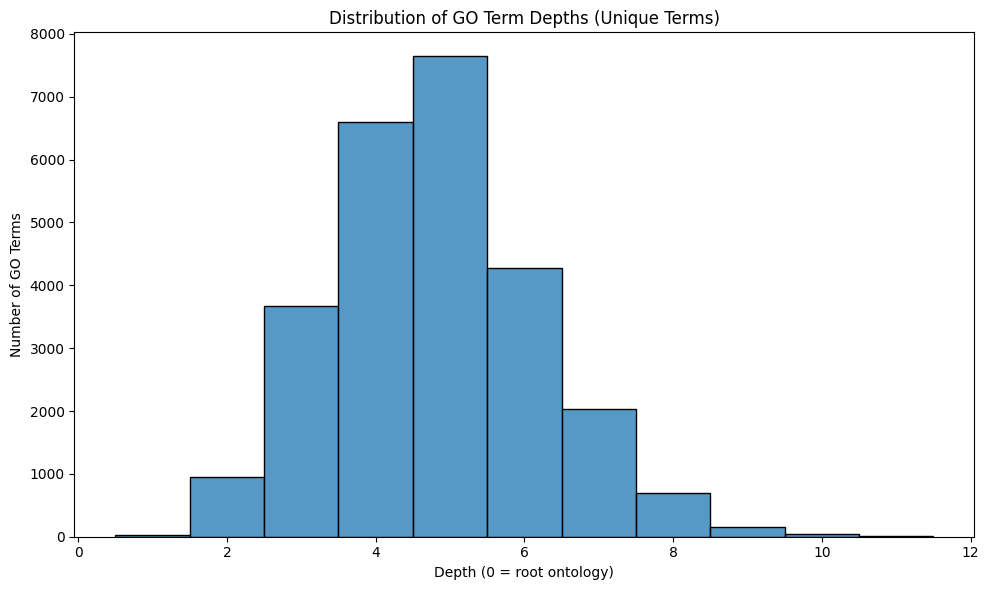

In [28]:
import obonet
import networkx as nx

# Load GO ontology
go_obo_path = get_data_path("cafa6", path.join("Train", "go-basic.obo"))
go_graph = obonet.read_obo(go_obo_path)

# Root GO terms (depth 0)
ROOT_TERMS = {
    "GO:0008150",  # biological_process (BPO)
    "GO:0005575",  # cellular_component (CCO)
    "GO:0003674",  # molecular_function (MFO)
}

# Calculate depth for each GO term (shortest path to any root)
def get_term_depth(term, graph, roots):
    if term in roots:
        return 0
    if term not in graph:
        return None
    min_depth = float('inf')
    for root in roots:
        try:
            # go-basic.obo edges point from child to parent (is_a relationship)
            depth = nx.shortest_path_length(graph, source=term, target=root)
            min_depth = min(min_depth, depth)
        except nx.NetworkXNoPath:
            continue
    return min_depth if min_depth != float('inf') else None

# Get unique terms from training data
unique_terms = terms_df["term"].unique()

# Calculate depth for each unique term (count each GO term only once)
unique_term_depths = []
for term in unique_terms:
    depth = get_term_depth(term, go_graph, ROOT_TERMS)
    if depth is not None:
        unique_term_depths.append(depth)

unique_depths_series = pd.Series(unique_term_depths)

print(f"Unique GO terms with valid depth: {len(unique_term_depths):,} / {len(unique_terms):,}")
print(f"\nDepth statistics (unique GO terms):")
print(unique_depths_series.describe())

# Plot histogram of depths (each GO term counted once)
plt.figure(figsize=(10, 6))
sns.histplot(x=unique_depths_series, bins=range(int(unique_depths_series.max()) + 2), discrete=True)
plt.xlabel("Depth (0 = root ontology)")
plt.ylabel("Number of GO Terms")
plt.title("Distribution of GO Term Depths (Unique Terms)")
plt.tight_layout()
plt.show()

**What is the distribution of IA for annotations?**

It is heavily right-skewed, with mean 2.31 and median 1.03. 

Unique GO terms with IA: 26,125 / 26,125

IA statistics (unique GO terms):
count    26125.000000
mean         2.310780
std          2.806843
min          0.000000
25%          0.000000
50%          1.034765
75%          3.857981
max         14.861014
Name: IA, dtype: float64


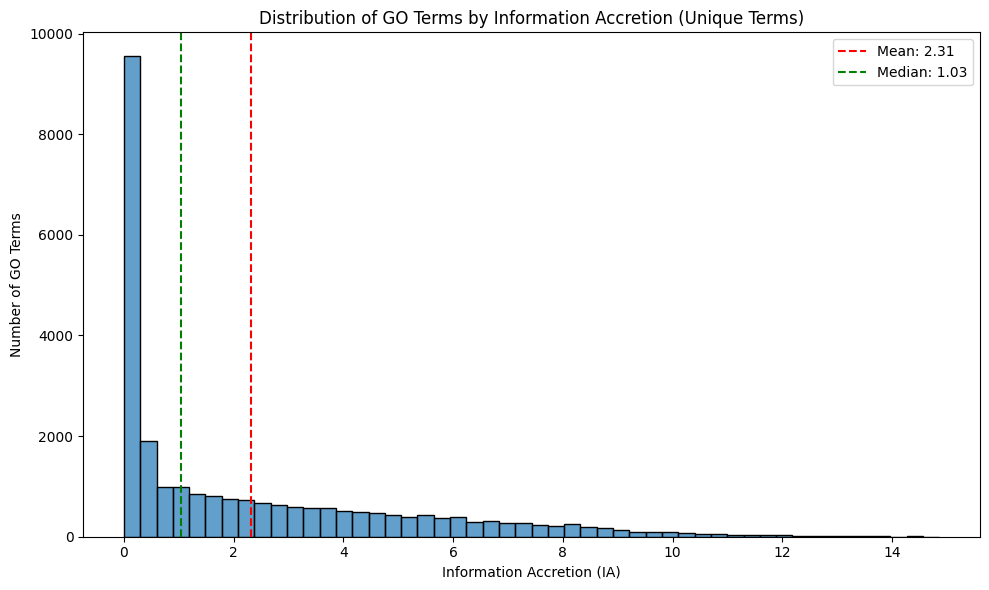

In [30]:
# Load IA data and get unique GO terms from training
ia_df = pd.read_csv(get_data_path("cafa6", "IA.tsv"), sep="\t", header=None, names=["GO_Term", "IA"])

# Get unique terms from training data
unique_training_terms = pd.DataFrame({"term": terms_df["term"].unique()})

# Merge IA with unique training terms (count each GO term only once)
unique_terms_with_ia = unique_training_terms.merge(ia_df, left_on="term", right_on="GO_Term", how="left")

print(f"Unique GO terms with IA: {unique_terms_with_ia['IA'].notna().sum():,} / {len(unique_terms_with_ia):,}")
print(f"\nIA statistics (unique GO terms):")
print(unique_terms_with_ia["IA"].describe())

# Create histogram of IA distribution (each GO term counted once)
plt.figure(figsize=(10, 6))
sns.histplot(data=unique_terms_with_ia, x="IA", bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("Information Accretion (IA)")
plt.ylabel("Number of GO Terms")
plt.title("Distribution of GO Terms by Information Accretion (Unique Terms)")

# Add mean and median lines
mean_ia = unique_terms_with_ia["IA"].mean()
median_ia = unique_terms_with_ia["IA"].median()
plt.axvline(mean_ia, color='red', linestyle='--', label=f'Mean: {mean_ia:.2f}')
plt.axvline(median_ia, color='green', linestyle='--', label=f'Median: {median_ia:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

**Does IA correlate with term frequency?**

There seems to not be a clear frequency, but the triangular shape suggests that any GO terms with high frequency can also have high IA. Likewise, terms with high IA cannot have high frequency. This is good because it means that our score does not rely entirely on predicting the rarest labels.

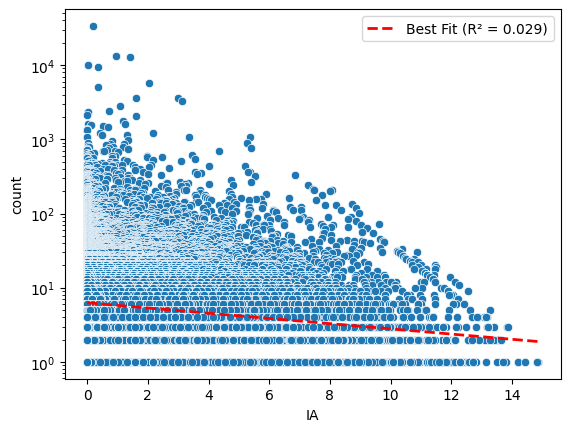

In [38]:
import numpy as np
from scipy import stats

freq_ia_df = term_counts.reset_index().merge(ia_df, left_on="term", right_on="GO_Term", how="left").drop(columns=["GO_Term"])

# Remove rows with missing IA values for the fit
freq_ia_clean = freq_ia_df.dropna(subset=['IA'])

# Fit a line in log space (log(count) vs IA)
log_counts = np.log(freq_ia_clean['count'])
slope, intercept, r_value, p_value, std_err = stats.linregress(freq_ia_clean['IA'], log_counts)

# Plot the scatter plot
sns.scatterplot(data=freq_ia_df, x="IA", y="count")
plt.yscale("log")

# Add the line of best fit
ia_range = np.array([freq_ia_clean['IA'].min(), freq_ia_clean['IA'].max()])
fit_log_counts = slope * ia_range + intercept
fit_counts = np.exp(fit_log_counts)
plt.plot(ia_range, fit_counts, 'r--', linewidth=2, label=f'Best Fit (R² = {r_value**2:.3f})')

plt.legend()
